In [1]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00


In [2]:
# Run this cell once to install all necessary packages
!pip install -q transformers datasets torch scikit-learn matplotlib seaborn pandas

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW                      # <-- changed line
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from datasets import Dataset as HFDataset
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive (if your data is stored there)
from google.colab import drive
drive.mount('/content/drive')

# ------------------------------
# Set paths and parameters
# ------------------------------
DATA_PATH = '/content/drive/MyDrive/intents_for_colab.csv'   # Update with your CSV path
MODEL_SAVE_DIR = '/content/drive/MyDrive/Peertopeer/models/intent_advanced'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# Training hyperparameters
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 2e-5
EARLY_STOPPING_PATIENCE = 3   # Stop if validation loss doesn't improve for 3 epochs
TEST_SIZE = 0.2                # Fraction of data to hold out for final test
VALIDATION_SIZE = 0.1          # Fraction of training data to use for validation

Mounted at /content/drive


In [5]:
df = pd.read_csv(DATA_PATH)
print(f"Original dataset size: {len(df)}")
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

# Ensure required columns exist
if 'message' not in df.columns or 'label' not in df.columns:
    raise ValueError("CSV must have columns 'message' and 'label'")

Original dataset size: 997
Columns: ['message', 'label']

First 5 rows:
                           message      label
0                    can you help?       help
1                  feedback option   feedback
2           sign out of educonnect     logout
3             study materials list  resources
4  how do i sign in to educonnect?      login



After cleaning: 993 rows

Number of unique intents: 18

Class distribution:
label
nlp_insights       68
help               65
admin              64
logout             63
chat               58
analytics          57
recommendations    57
resources          56
quiz               55
feedback           52
signup             52
study_group        51
login              51
timer              51
next_topic         51
profile            49
password_reset     48
dashboard          45
Name: count, dtype: int64


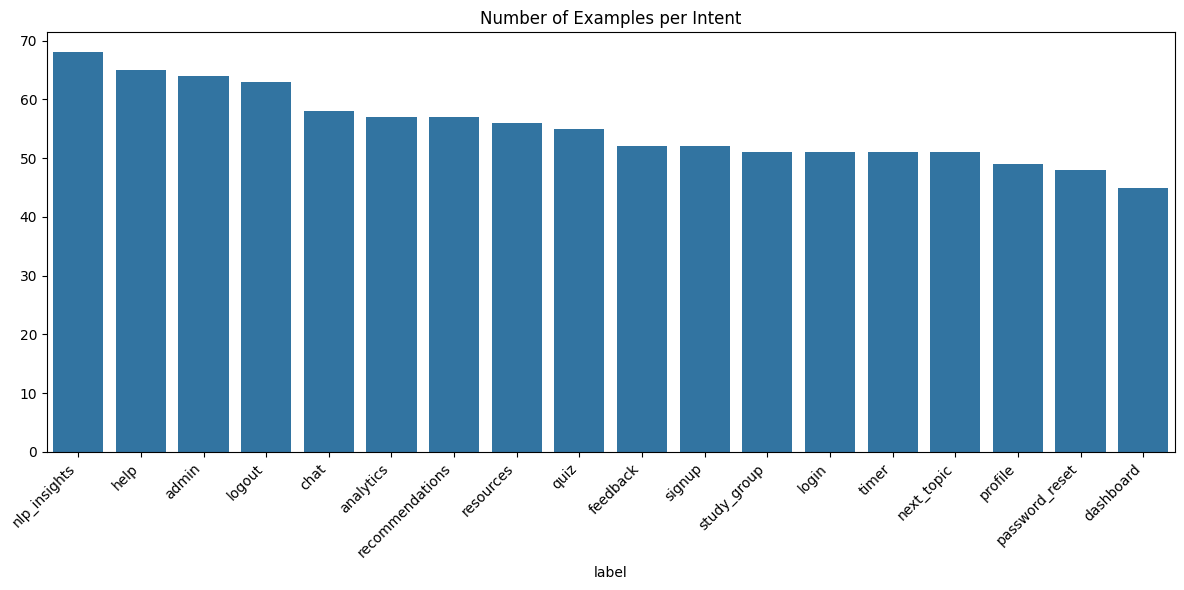


Message length stats:
count    993.000000
mean      16.265861
std        4.712267
min        3.000000
25%       13.000000
50%       16.000000
75%       19.000000
max       36.000000
Name: msg_len, dtype: float64


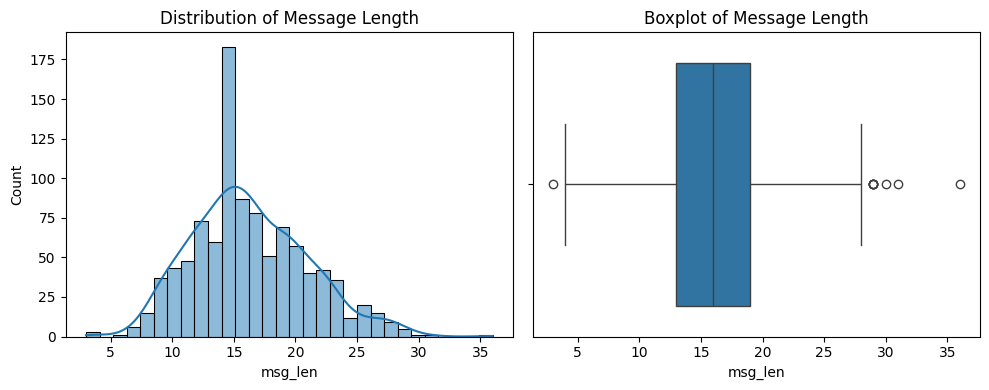


Sample messages per intent (first 2):
  nlp_insights: ['topic discovery', 'nlp page']
  help: ['can you help?', 'how does this work?']
  admin: ['admin users list', 'admin controls']
  logout: ['sign out of educonnect', 'sign out button']
  chat: ['chat with partners', 'chat list']


In [6]:
# Basic cleaning
df.dropna(subset=['message', 'label'], inplace=True)
df['message'] = df['message'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip().str.lower()
df = df[(df['message'].str.len() > 0) & (df['label'].str.len() > 0)]
df.drop_duplicates(subset=['message', 'label'], inplace=True)

print(f"\nAfter cleaning: {len(df)} rows")

# Class distribution
label_counts = df['label'].value_counts()
print(f"\nNumber of unique intents: {len(label_counts)}")
print("\nClass distribution:")
print(label_counts)

# Plot class distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=45, ha='right')
plt.title('Number of Examples per Intent')
plt.tight_layout()
plt.show()

# Message length analysis
df['msg_len'] = df['message'].apply(len)
print(f"\nMessage length stats:")
print(df['msg_len'].describe())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['msg_len'], bins=30, kde=True)
plt.title('Distribution of Message Length')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['msg_len'])
plt.title('Boxplot of Message Length')
plt.tight_layout()
plt.show()

# Show sample messages per intent
print("\nSample messages per intent (first 2):")
for label in label_counts.index[:5]:   # show first 5 intents
    samples = df[df['label'] == label]['message'].head(2).tolist()
    print(f"  {label}: {samples}")

In [7]:
##Encode Labels and Split Data
unique_labels = df['label'].unique().tolist()
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}
df['label_id'] = df['label'].map(label2id)

print(f"\nLabel mapping: {label2id}")

# Train / Validation / Test split
train_val_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, stratify=df['label_id'], random_state=42
)

train_df, val_df = train_test_split(
    train_val_df, test_size=VALIDATION_SIZE, stratify=train_val_df['label_id'], random_state=42
)

print(f"\nTrain size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")


Label mapping: {'help': 0, 'feedback': 1, 'logout': 2, 'resources': 3, 'login': 4, 'signup': 5, 'quiz': 6, 'chat': 7, 'timer': 8, 'study_group': 9, 'dashboard': 10, 'analytics': 11, 'profile': 12, 'admin': 13, 'next_topic': 14, 'password_reset': 15, 'nlp_insights': 16, 'recommendations': 17}

Train size: 714, Validation size: 80, Test size: 199


In [8]:
##Compute Class Weights (for imbalanced data)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_id']),
    y=train_df['label_id']
)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

Class weights: tensor([0.8440, 1.0439, 0.8815, 0.9917, 1.0721, 1.0439, 0.9917, 0.9675, 1.0721,
        1.0721, 1.2396, 0.9675, 1.1333, 0.8623, 1.0721, 1.1667, 0.8095, 0.9917])


In [9]:
##Tokenization and Dataset Creation
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples['message'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN
    )

# Convert pandas DataFrames to Hugging Face Dataset
train_dataset = HFDataset.from_pandas(train_df[['message', 'label_id']])
val_dataset = HFDataset.from_pandas(val_df[['message', 'label_id']])
test_dataset = HFDataset.from_pandas(test_df[['message', 'label_id']])

# Apply tokenization
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Rename label column to 'labels' (expected by Trainer)
train_dataset = train_dataset.rename_column('label_id', 'labels')
val_dataset = val_dataset.rename_column('label_id', 'labels')
test_dataset = test_dataset.rename_column('label_id', 'labels')

# Set format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/714 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/199 [00:00<?, ? examples/s]

In [10]:
##Load Model and Move to Device
num_labels = len(unique_labels)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"Using device: {device}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda


In [12]:
##Prepare DataLoaders, Optimizer, Scheduler, and Loss Function
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(device))

In [13]:
##Training Loop with Validation and Early Stopping
best_val_loss = float('inf')
patience_counter = 0
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(EPOCHS):
    print(f"\n========== Epoch {epoch+1}/{EPOCHS} ==========")

    # Training phase
    model.train()
    total_train_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = loss_fn(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval()
    total_val_loss = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, labels)
            total_val_loss += loss.item()

            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    val_acc = accuracy_score(all_labels, all_preds)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        model.save_pretrained(MODEL_SAVE_DIR)
        tokenizer.save_pretrained(MODEL_SAVE_DIR)
        print(f"  -> Best model saved to {MODEL_SAVE_DIR}")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break


========== Epoch 1/10 ==========
Train Loss: 2.7845 | Val Loss: 2.5352 | Val Acc: 0.5750


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> Best model saved to /content/drive/MyDrive/Peertopeer/models/intent_advanced

========== Epoch 2/10 ==========
Train Loss: 2.2535 | Val Loss: 1.9012 | Val Acc: 0.8000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> Best model saved to /content/drive/MyDrive/Peertopeer/models/intent_advanced

========== Epoch 3/10 ==========
Train Loss: 1.6367 | Val Loss: 1.3740 | Val Acc: 0.8625


...

  -> Best model saved to /content/drive/MyDrive/Peertopeer/models/intent_advanced

========== Epoch 9/10 ==========
Train Loss: 0.3318 | Val Loss: 0.4323 | Val Acc: 0.9375


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> Best model saved to /content/drive/MyDrive/Peertopeer/models/intent_advanced

========== Epoch 10/10 ==========
Train Loss: 0.3043 | Val Loss: 0.4204 | Val Acc: 0.9375


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  -> Best model saved to /content/drive/MyDrive/Peertopeer/models/intent_advanced


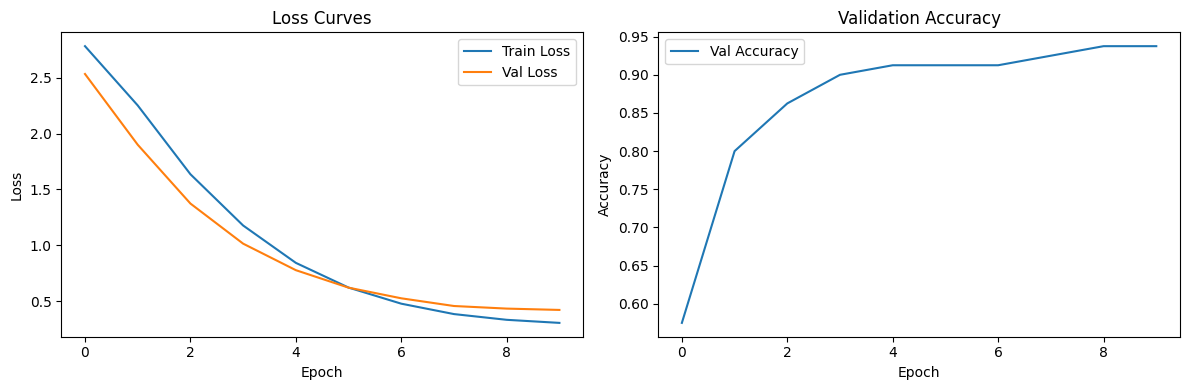

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Validation Accuracy')
plt.tight_layout()
plt.show()


========== Final Evaluation on Test Set ==========
Test Accuracy:  0.9548
Test Weighted F1: 0.9535

Classification Report:
                 precision    recall  f1-score   support

           help       0.93      1.00      0.96        13
       feedback       1.00      1.00      1.00        10
         logout       1.00      1.00      1.00        13
      resources       0.91      0.91      0.91        11
          login       1.00      1.00      1.00        10
         signup       0.91      1.00      0.95        10
           quiz       0.85      1.00      0.92        11
           chat       1.00      1.00      1.00        12
          timer       1.00      1.00      1.00        10
    study_group       1.00      0.80      0.89        10
      dashboard       1.00      1.00      1.00         9
      analytics       1.00      1.00      1.00        11
        profile       1.00      1.00      1.00        10
          admin       1.00      0.85      0.92        13
     next_topic     

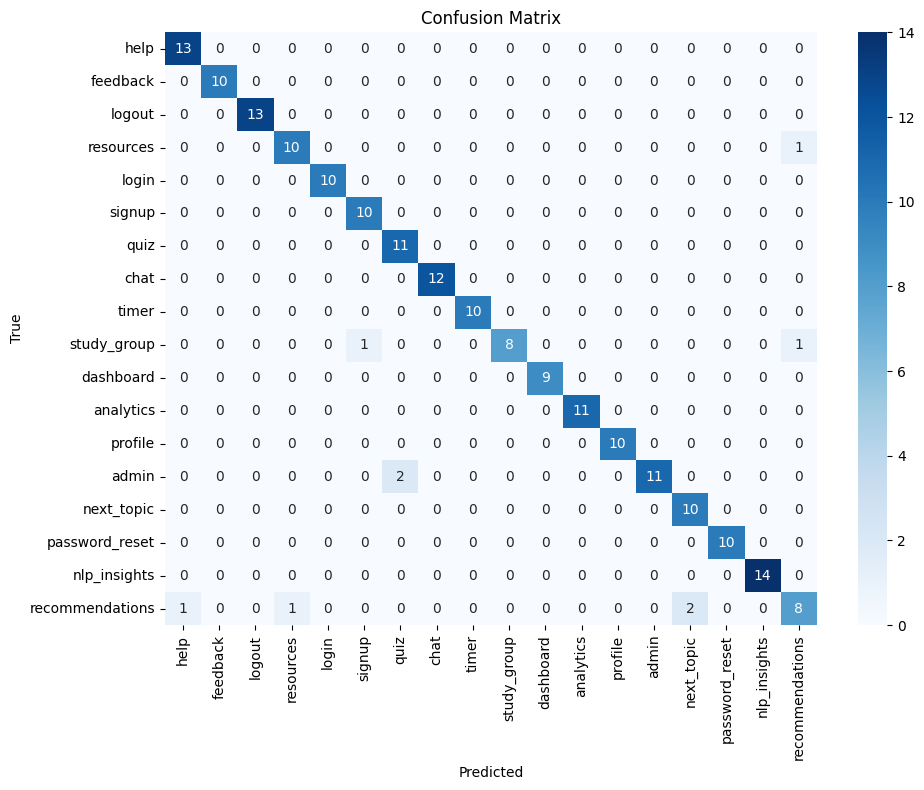

In [15]:
print("\n========== Final Evaluation on Test Set ==========")
model.eval()
all_test_preds = []
all_test_labels = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_test_labels, all_test_preds)
test_f1 = f1_score(all_test_labels, all_test_preds, average='weighted')
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Weighted F1: {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(all_test_labels, all_test_preds, target_names=unique_labels))

# Confusion matrix
cm = confusion_matrix(all_test_labels, all_test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=unique_labels, yticklabels=unique_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [16]:
def predict_intent(text, model, tokenizer, device, id2label):
    model.eval()
    inputs = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        return_tensors='pt'
    ).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        pred_id = torch.argmax(logits, dim=-1).item()
    return id2label[pred_id]

sample_texts = [
    "how do i log in?",
    "show me resources",
    "i need study partners",
    "start a timer"
]
print("\n========== Sample Predictions ==========")
for text in sample_texts:
    pred = predict_intent(text, model, tokenizer, device, id2label)
    print(f"Text: '{text}' -> Predicted Intent: {pred}")


========== Sample Predictions ==========
Text: 'how do i log in?' -> Predicted Intent: login
Text: 'show me resources' -> Predicted Intent: resources
Text: 'i need study partners' -> Predicted Intent: study_group
Text: 'start a timer' -> Predicted Intent: timer


In [17]:
model.save_pretrained(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)
print(f"Model saved to {MODEL_SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/Peertopeer/models/intent_advanced
